# Module 3: Intent Classifier & Routing (تصنيف النوايا والتوجيه الذكي)
**NLP Final Task 2026 - RAG-Based E-commerce Customer Support Chatbot**

## Overview
The Intent Classifier is the core traffic controller of the chatbot architecture. Rather than treating all customer messages identically, it determines the true goal of the user to select the optimal handling pathway:
- **`greeting_smalltalk`**: Simple friendly greetings, goodbyes, gratitude. Answered directly with pre-crafted templates (no RAG needed, saving compute & latency).
- **`order_status`**: Questions about order tracking, delivery timelines, and shipping options. Routed to RAG grounded in knowledge base.
- **`order_management`**: Requests to cancel, modify, or place orders. Routed to RAG with appropriate action instructions.
- **`billing_and_refunds`**: Invoices, payment problems, refund policies, and fee inquiries. Routed to RAG.
- **`account_management`**: Password recovery, registration, account creation/editing/deletion. Routed to RAG.
- **`complaint`**: Angry reviews, customer service escalation requests. Flags priority handling and human handoff.
- **`out_of_scope`**: Unrelated topics (general trivia, programming, etc.). Politely declines and redirects to store support.

---
### Dataset & Label Condensation
- **Dataset**: `bitext/Bitext-customer-support-llm-chatbot-training-dataset` (26,872 gold-labeled samples across 27 fine-grained intents).
- We condense the 27 intents into the 7 recommended routing categories specified in the project assignment.


In [1]:
import os
import re
import json
import joblib
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

print("Imports loaded successfully!")


e:\ITI\NLP\nlp-support-chatbot\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Imports loaded successfully!


## 1. Load Bitext Dataset & Condense 27 Intents to 7 Categories

In [2]:
print("Loading bitext customer support dataset...")
ds = load_dataset("bitext/Bitext-customer-support-llm-chatbot-training-dataset")['train']

INTENT_MAPPING = {
    # order_status
    "track_order": "order_status",
    "delivery_options": "order_status",
    "delivery_period": "order_status",
    
    # order_management
    "cancel_order": "order_management",
    "change_order": "order_management",
    "place_order": "order_management",
    "change_shipping_address": "order_management",
    "set_up_shipping_address": "order_management",
    
    # billing_and_refunds
    "check_invoice": "billing_and_refunds",
    "get_invoice": "billing_and_refunds",
    "check_payment_methods": "billing_and_refunds",
    "payment_issue": "billing_and_refunds",
    "check_refund_policy": "billing_and_refunds",
    "get_refund": "billing_and_refunds",
    "track_refund": "billing_and_refunds",
    "check_cancellation_fee": "billing_and_refunds",
    
    # account_management
    "create_account": "account_management",
    "edit_account": "account_management",
    "delete_account": "account_management",
    "switch_account": "account_management",
    "recover_password": "account_management",
    "registration_problems": "account_management",
    "newsletter_subscription": "account_management",
    
    # complaint
    "complaint": "complaint",
    "review": "complaint",
    
    # customer contact
    "contact_customer_service": "account_management",
    "contact_human_agent": "complaint"
}

SMALLTALK_EXAMPLES = [
    "hello", "hi there", "good morning", "good evening", "hey", "howdy",
    "how are you doing today?", "is anyone available?", "hello support team",
    "thank you so much", "thanks for your help", "appreciate your assistance",
    "that was very helpful thank you", "many thanks", "thanks a lot",
    "goodbye", "bye bye", "have a great day", "see you later", "talk to you soon",
    "ok thanks bye", "good night", "catch you later"
] * 40

OUT_OF_SCOPE_EXAMPLES = [
    "what is the capital of france?", "who won the world cup in 2022?",
    "tell me a funny joke", "write a python code to reverse a string",
    "what is the weather like in tokyo today?", "can you solve 2x + 5 = 15?",
    "recommend a good science fiction movie", "how to bake a chocolate cake?",
    "what time is it in new york?", "tell me about quantum computing",
    "who is the ceo of google?", "what is the meaning of life?",
    "translate this sentence to spanish", "play my favorite music playlist"
] * 65

def clean_instruction(text):
    text = text.lower()
    text = re.sub(r"\{\{[^}]+\}\}", " ", text)
    text = re.sub(r"[^a-zA-Z0-9\s.,!?']", " ", text)
    return " ".join(text.split())

texts = [clean_instruction(row['instruction']) for row in ds]
labels = [INTENT_MAPPING.get(row['intent'], "out_of_scope") for row in ds]

for s in SMALLTALK_EXAMPLES:
    texts.append(clean_instruction(s))
    labels.append("greeting_smalltalk")
for o in OUT_OF_SCOPE_EXAMPLES:
    texts.append(clean_instruction(o))
    labels.append("out_of_scope")

df = pd.DataFrame({"text": texts, "intent": labels})
print(f"Total Dataset Size: {len(df):,}")
df.head()


Loading bitext customer support dataset...


Total Dataset Size: 28,702


,text,intent
0,question about cancelling order,order_management
1,i have a question about cancelling oorder,order_management
2,i need help cancelling puchase,order_management
3,i need to cancel purchase,order_management
4,"i cannot afford this order, cancel purchase",order_management


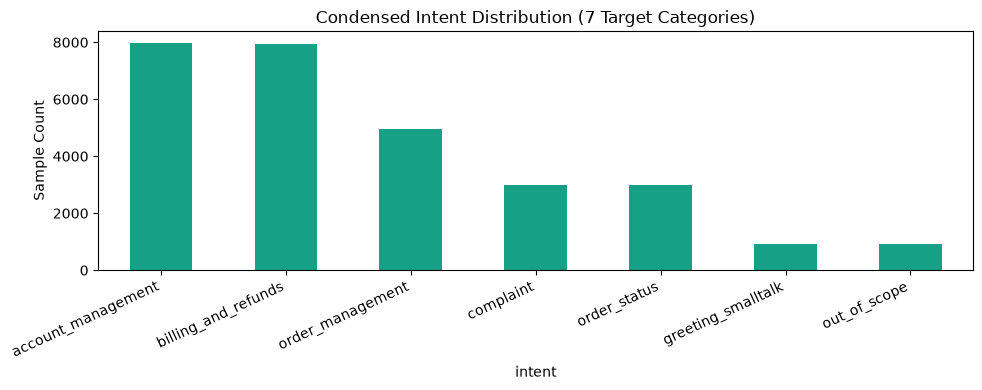

In [3]:
plt.figure(figsize=(10, 4))
df['intent'].value_counts().plot(kind='bar', color='#16a085')
plt.title("Condensed Intent Distribution (7 Target Categories)")
plt.ylabel("Sample Count")
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()


## 2. Train / Test Split & Pipeline Architecture

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    df['text'], df['intent'], test_size=0.20, random_state=42, stratify=df['intent']
)
print(f"Training samples: {len(X_train):,}")
print(f"Testing samples: {len(X_test):,}")

pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=True, min_df=2, max_features=25000)),
    ('clf', LogisticRegression(C=3.0, max_iter=1000, class_weight='balanced', random_state=42))
])

print("Training Intent Classifier Pipeline...")
pipeline.fit(X_train, y_train)
print("Model trained successfully!")


Training samples: 22,961
Testing samples: 5,741
Training Intent Classifier Pipeline...
Model trained successfully!


## 3. Evaluation on Unseen Test Set

In [5]:
test_preds = pipeline.predict(X_test)
acc = accuracy_score(y_test, test_preds)
macro_f1 = f1_score(y_test, test_preds, average='macro')

print(f"Test Accuracy: {acc:.2%}")
print(f"Test Macro F1-Score: {macro_f1:.4f}\n")

unique_intents = sorted(df['intent'].unique().tolist())
print(classification_report(y_test, test_preds, target_names=unique_intents, digits=4))


Test Accuracy: 99.69%
Test Macro F1-Score: 0.9970

                     precision    recall  f1-score   support

 account_management     0.9975    0.9962    0.9969      1597
billing_and_refunds     0.9987    0.9981    0.9984      1588
          complaint     0.9934    1.0000    0.9967       599
 greeting_smalltalk     1.0000    1.0000    1.0000       184
   order_management     0.9950    0.9960    0.9955       993
       order_status     0.9966    0.9916    0.9941       598
       out_of_scope     0.9945    1.0000    0.9973       182

           accuracy                         0.9969      5741
          macro avg     0.9965    0.9974    0.9970      5741
       weighted avg     0.9969    0.9969    0.9969      5741



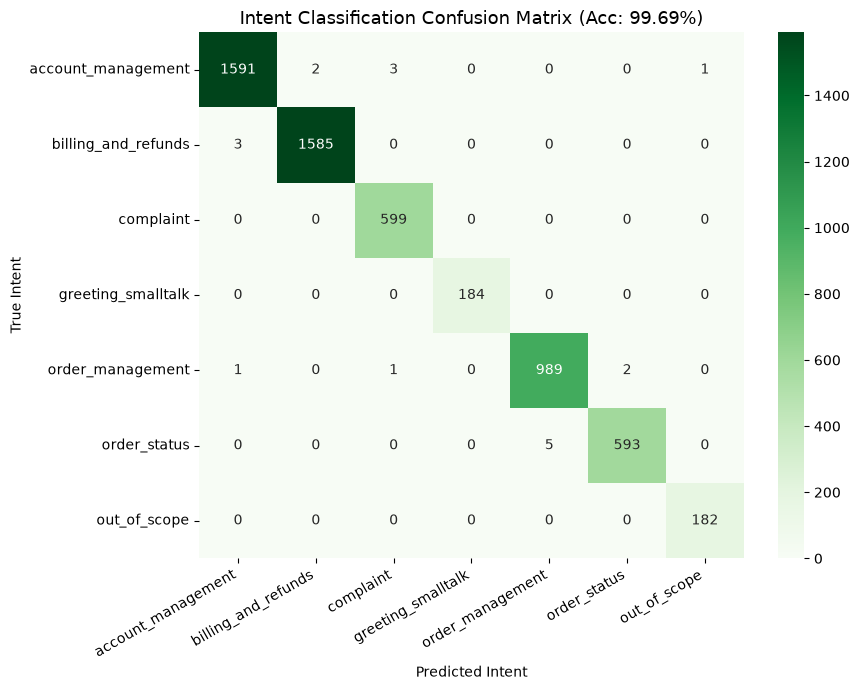

In [6]:
cm = confusion_matrix(y_test, test_preds, labels=unique_intents)

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=unique_intents, yticklabels=unique_intents)
plt.title(f"Intent Classification Confusion Matrix (Acc: {acc:.2%})", fontsize=13)
plt.xlabel("Predicted Intent")
plt.ylabel("True Intent")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


## 4. End-to-End Chatbot Routing Simulation

The chatbot uses the predicted intent (and confidence threshold) to route the message:
1. **`greeting_smalltalk`**: Handled with zero-latency canned templates without querying the vector database.
2. **`complaint`**: Flagged with high urgency for human support escalation.
3. **`order_status`, `order_management`, `billing_and_refunds`, `account_management`**: Passes query to RAG knowledge base.
4. **`out_of_scope`**: Polite refusal with offer to connect to a live representative.


In [7]:
test_queries = [
    ("Hi, good afternoon!", "greeting_smalltalk"),
    ("Where is my package and how long does standard shipping take?", "order_status"),
    ("I need to cancel order #48291 please", "order_management"),
    ("Can I get a full refund for my damaged item?", "billing_and_refunds"),
    ("I forgot my password, how can I recover my account?", "account_management"),
    ("Your service is awful, I want to file a formal complaint!", "complaint"),
    ("What is the distance between the Earth and the Moon?", "out_of_scope")
]

ROUTING_ACTIONS = {
    "greeting_smalltalk": "Direct Reply (Small Talk - No RAG needed)",
    "order_status": "Route to RAG Knowledge Base (Shipping & Delivery)",
    "order_management": "Route to RAG Knowledge Base (Order Modification)",
    "billing_and_refunds": "Route to RAG Knowledge Base (Refunds & Invoices)",
    "account_management": "Route to RAG Knowledge Base (Account Guide)",
    "complaint": "Flag for Human Agent Escalation + Apologetic Tone",
    "out_of_scope": "Polite Fallback (Offer Live Agent)"
}

results = []
for q, expected in test_queries:
    probs = pipeline.predict_proba([q])[0]
    max_prob = np.max(probs)
    pred = pipeline.classes_[np.argmax(probs)]
    
    # Out of scope confidence threshold
    if max_prob < 0.35:
        pred = "out_of_scope"
        
    results.append({
        'Query': q,
        'Expected Intent': expected,
        'Predicted Intent': pred,
        'Confidence': f"{max_prob:.1%}",
        'Chatbot Routing Action': ROUTING_ACTIONS.get(pred, "Standard RAG")
    })

pd.DataFrame(results)


,Query,Expected Intent,Predicted Intent,Confidence,Chatbot Routing Action
0,"Hi, good afternoon!",greeting_smalltalk,greeting_smalltalk,99.5%,Direct Reply (Small Talk - No RAG needed)
1,Where is my package and how long does standard...,order_status,order_status,86.4%,Route to RAG Knowledge Base (Shipping & Delivery)
2,I need to cancel order #48291 please,order_management,order_management,99.6%,Route to RAG Knowledge Base (Order Modification)
3,Can I get a full refund for my damaged item?,billing_and_refunds,billing_and_refunds,94.2%,Route to RAG Knowledge Base (Refunds & Invoices)
4,"I forgot my password, how can I recover my acc...",account_management,account_management,98.0%,Route to RAG Knowledge Base (Account Guide)
5,"Your service is awful, I want to file a formal...",complaint,complaint,97.6%,Flag for Human Agent Escalation + Apologetic Tone
6,What is the distance between the Earth and the...,out_of_scope,out_of_scope,95.7%,Polite Fallback (Offer Live Agent)


## 5. Export Model Pipeline

In [8]:
os.makedirs("../models", exist_ok=True)
joblib.dump(pipeline, "../models/intent_classifier.pkl")
print("Saved models/intent_classifier.pkl successfully!")


Saved models/intent_classifier.pkl successfully!
